In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import os
import shap
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv


## Problem Statement

Alzheimer’s disease is a neurodegenerative disorder associated with progressive decline in memory, cognition, and daily functioning. Early identification of patterns associated with Alzheimer’s disease is important for research and clinical decision-making.

In this project, I use a public Alzheimer’s disease dataset to build an exploratory machine learning model that predicts whether a patient has an Alzheimer’s diagnosis based on demographic, lifestyle, medical history, cognitive, and functional features.

The main goal of this project is not to create a clinically validated diagnostic tool, but to practice a full biomedical machine learning workflow. 

This includes loading and cleaning data, performing exploratory data analysis, training baseline and XGBoost models, evaluating model performance, and interpreting which features contributed most to the model’s predictions.

The target variable for this project is Alzheimer’s disease diagnosis, and the model is trained as a binary classification problem.

## Dataset Overview

In [2]:
data = pd.read_csv("/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv")
data.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
data.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

## Exploratory Data Analysis

In [4]:
# Here, we check how many diagnosis there are
# and explore the dataset to understand diagnosis distribution, missing values, and key clinical patterns.
diagnosis_counts = data['Diagnosis'].value_counts()
print(diagnosis_counts)

Diagnosis
0    1389
1     760
Name: count, dtype: int64


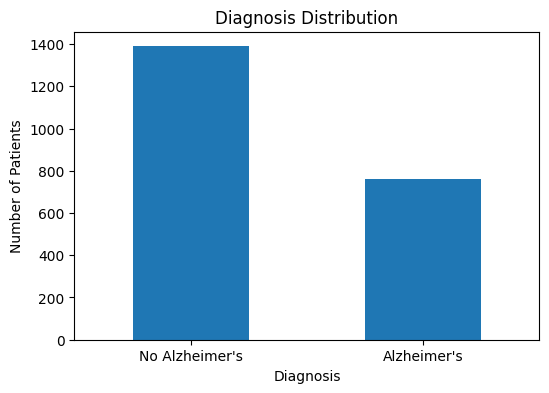

In [5]:
# Check how many patients are in each diagnosis group
diagnosis_counts = data["Diagnosis"].value_counts().sort_index()

# Rename 0 and 1 to clearer labels
label_map = {
    0: "No Alzheimer's",
    1: "Alzheimer's"
}

diagnosis_counts.index = diagnosis_counts.index.map(label_map)

# Create bar plot
plt.figure(figsize=(6, 4))
diagnosis_counts.plot(kind="bar")

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

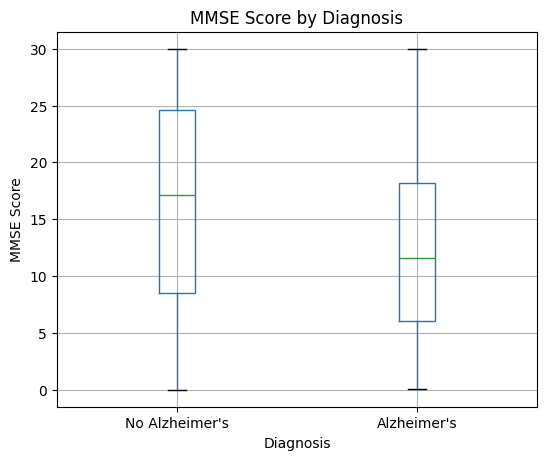

In [6]:
# Compare MMSE scores by diagnosis group
data.boxplot(column="MMSE", by="Diagnosis", figsize=(6, 5))

plt.title("MMSE Score by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("MMSE Score")
plt.xticks([1, 2], ["No Alzheimer's", "Alzheimer's"])

plt.show()

The boxplot compares MMSE scores between patients without Alzheimer's and patients with Alzheimer's. Patients without Alzheimer's generally had higher MMSE scores, while patients with Alzheimer's tended to have lower MMSE scores. This pattern is expected because MMSE measures cognitive function, and lower scores are associated with greater cognitive impairment.

However, the two groups still overlap, meaning MMSE alone does not perfectly separate Alzheimer's and non-Alzheimer's cases. Some patients with Alzheimer's had relatively high MMSE scores, while some patients without Alzheimer's had lower scores. This suggests that MMSE is an important predictor, but the model should still use multiple features rather than relying on MMSE alone.

Because MMSE is closely related to cognitive diagnosis, this feature should also be interpreted carefully in the leakage investigation. Its strong relationship with the target may help explain the model's high performance.

In [7]:
# Prepare the data by separating features and target, removing unnecessary columns, and creating train/test sets.
features = ['Age', 'Gender', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness']
X = data[features]
y = data.Diagnosis

# Count missing values in each column
missing_values = data.isnull().sum()

# Keep only columns with missing values
missing_values = missing_values[missing_values > 0]

# Plot missing values if any exist
if len(missing_values) > 0:
    plt.figure(figsize=(10, 5))
    missing_values.sort_values(ascending=False).plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("No missing values found.")

# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, stratify = y, random_state=0)


categorical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and 
                        X_train_full[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='constant')

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

No missing values found.


## Baseline Model: Random Forest

In [8]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=0
    ))
])

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_valid)
rf_probabilities = rf_model.predict_proba(X_valid)[:, 1]

# Evaluate the Random Forest model
print("Random Forest Accuracy:", accuracy_score(y_valid, rf_predictions))
print("Random Forest ROC-AUC:", roc_auc_score(y_valid, rf_probabilities))
print("\nClassification Report:")
print(classification_report(y_valid, rf_predictions))


Random Forest Accuracy: 0.9418604651162791
Random Forest ROC-AUC: 0.9456526883756154

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       278
           1       0.95      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430



The Random Forest model achieved an accuracy of approximately 94.2% and a ROC-AUC score of approximately 0.946 on the validation set. This suggests that the model performed strongly overall and was able to separate Alzheimer's and non-Alzheimer's cases well across different classification thresholds.

For the No Alzheimer's class, the model achieved a precision of 0.94, recall of 0.97, and F1-score of 0.96. This means the model was especially strong at identifying patients without Alzheimer's. For the Alzheimer's class, the model achieved a precision of 0.95, recall of 0.88, and F1-score of 0.91. The high precision means that when the model predicted Alzheimer's, it was usually correct, but the lower recall means that some Alzheimer's cases were still missed.

Overall, these results show strong model performance, but the Alzheimer's recall should be considered carefully because false negatives are important in a medical context. A missed Alzheimer's case could be more concerning than a false positive, so the model should not be evaluated by accuracy alone. The high ROC-AUC is promising, but it should also be interpreted alongside feature importance and leakage analysis to determine whether the model is learning generalizable patterns or relying on highly diagnostic features.

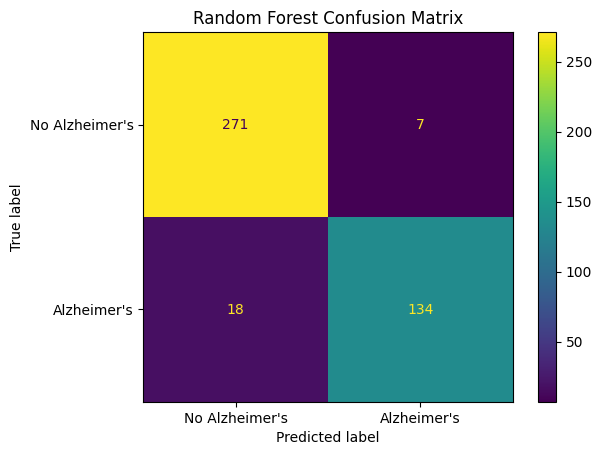

In [9]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    rf_predictions,
    display_labels=["No Alzheimer's", "Alzheimer's"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

The confusion matrix shows how the Random Forest model classified patients into "No Alzheimer's" and "Alzheimer's." The model correctly predicted 271 patients without Alzheimer's and 134 patients with Alzheimer's. It made 7 false positive errors, where patients without Alzheimer's were predicted to have Alzheimer's, and 18 false negative errors, where patients with Alzheimer's were predicted as not having Alzheimer's.

Overall, the model performed strongly, correctly classifying 405 out of 430 patients. However, the false negatives are especially important in a medical context because they represent Alzheimer's cases that the model missed. This suggests that while the model has high accuracy, recall for the Alzheimer's class should be considered carefully.

## Main Model: XGBClassifier

In [10]:
# Train an XGBoost classifier to predict Alzheimer’s diagnosis from the selected features.
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=0,
        n_estimators=500,
        learning_rate=0.1,
    ))

])
# Fitting the model
my_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='constant'),
                                                  ['Age', 'Gender',
                                                   'EducationLevel', 'BMI',
                                                   'Smoking',
                                                   'AlcoholConsumption',
                                                   'PhysicalActivity',
                                                   'DietQuality',
                                                   'SleepQuality',
                                                   'FamilyHistoryAlzheimers',
                                                   'CardiovascularDisease',
                                                   'Diabetes', 'Depression',
                                                   'HeadInjury', 'Hypertension',
                                                   'SystolicBP', 'DiastolicB...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

## Evaluation

In [11]:
# Evaluate model performance using accuracy, precision, recall, F1 score, ROC-AUC, and a confusion matrix.
xgb_probabilities = my_pipeline.predict_proba(X_valid)[:, 1]
prediction = my_pipeline.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, prediction))
print("XGB ROC-AUC:", roc_auc_score(y_valid, xgb_probabilities))
print(confusion_matrix(y_valid, prediction))
print(classification_report(y_valid, prediction))

Accuracy: 0.9488372093023256
XGB ROC-AUC: 0.9470607724346838
[[270   8]
 [ 14 138]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.95      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



The XGBClassifier achieved an accuracy of approximately 94.9% on the validation set. The model correctly classified 408 out of 430 patients, with 270 true negatives and 138 true positives. It made 8 false positive errors, where patients without Alzheimer's were incorrectly predicted to have Alzheimer's, and 14 false negative errors, where patients with Alzheimer's were incorrectly predicted as not having Alzheimer's.

The classification report shows strong performance for both classes. For the No Alzheimer's class, the model achieved a precision of 0.95, recall of 0.97, and F1-score of 0.96. For the Alzheimer's class, the model achieved a precision of 0.95, recall of 0.91, and F1-score of 0.93. The Alzheimer's recall is especially important because it measures how many true Alzheimer's cases the model successfully detected.

The ROC-AUC score of approximately 0.947 suggests that the model can separate Alzheimer's and non-Alzheimer's cases well. However, ROC-AUC should ideally be calculated using predicted probabilities instead of final class predictions. Overall, the XGBClassifier performed strongly, but the false negatives should still be considered carefully because missed Alzheimer's cases are clinically important.

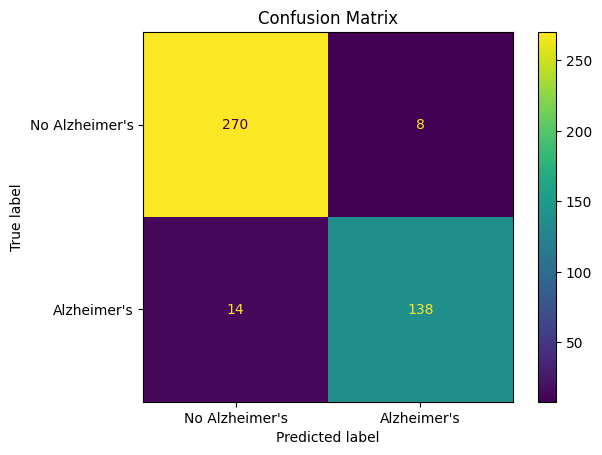

In [12]:
# Confusion matrix graph
cm = confusion_matrix(y_valid, prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Alzheimer's", "Alzheimer's"])
disp.plot()

plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows how the model classified patients into class 0 and class 1, where class 0 represents no Alzheimer's and class 1 represents Alzheimer's. The model correctly predicted 270 patients without Alzheimer's and 138 patients with Alzheimer's. It made 8 false positive errors, where patients without Alzheimer's were incorrectly predicted to have Alzheimer's, and 14 false negative errors, where patients with Alzheimer's were incorrectly predicted as not having Alzheimer's.

Overall, the model correctly classified 408 out of 430 patients, giving an accuracy of about 94.9%. The false negatives are especially important in a medical context because they represent Alzheimer's cases that the model failed to detect. This means the model performs well overall, but recall for the Alzheimer's class should still be considered carefully.

## Overfitting Check

In [13]:
train_preds = my_pipeline.predict(X_train)
valid_preds = my_pipeline.predict(X_valid)

print("Training Accuracy:", accuracy_score(y_train, train_preds))
print("Validation Accuracy:", accuracy_score(y_valid, valid_preds))

Training Accuracy: 1.0
Validation Accuracy: 0.9488372093023256


## Leakage Investigation

The training accuracy of 1.0 vs. validation accuracy of ~0.96 suggests the model 
is overfitting. To address this, I tune key regularization parameters 
(max_depth, subsample, colsample_bytree, reg_lambda) alongside n_estimators and 
learning_rate using RandomizedSearchCV.

In [14]:
param_grid = {
    'model__max_depth': [3, 4, 6],          # shallower trees = less overfitting
    'model__n_estimators': [100, 300, 500], # number of boosting rounds
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.9, 1.0],        # row sampling to reduce overfitting
    'model__colsample_bytree': [0.7, 0.9, 1.0], # feature sampling to reduce overfitting
    'model__reg_lambda': [1, 5, 10]             # L2 regularization strength
}

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=0))
])

grid_search = RandomizedSearchCV(
    base_pipeline,
    param_grid,
    n_iter=40,          # number of random combinations to try (instead of all 729)
    cv=5,
    scoring='roc_auc',
    random_state=0,     
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

best_pipeline = grid_search.best_estimator_
best_preds = best_pipeline.predict(X_valid)
best_probs = best_pipeline.predict_proba(X_valid)[:, 1]

print("Validation Accuracy:", accuracy_score(y_valid, best_preds))
print("Validation ROC-AUC:", roc_auc_score(y_valid, best_probs))

# Check whether the overfitting gap has closed
train_preds_best = best_pipeline.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_preds_best))
print("Validation Accuracy:", accuracy_score(y_valid, best_preds))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 10, 'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}
Best CV ROC-AUC: 0.9552067024833727
Validation Accuracy: 0.9511627906976744
Validation ROC-AUC: 0.9449308973873533
Training Accuracy: 0.9621873182082606
Validation Accuracy: 0.9511627906976744


In [15]:
# Cross-validated ROC-AUC
cv_scores = cross_val_score(
    my_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Average Cross-Validated ROC-AUC:", cv_scores.mean())

Average Cross-Validated ROC-AUC: 0.9479634703789316


In [16]:
# Identify which features contributed most to the XGBoost model’s predictions.

# First fit the pipeline
my_pipeline.fit(X_train, y_train)

# Get the actual XGBoost model from inside the pipeline
xgb_model = my_pipeline.named_steps["model"]

# Now get feature importances
importance_values = xgb_model.feature_importances_

# Put feature names and importance values into a DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance_values
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top features
feature_importance.head(10)

,Feature,Importance
24,BehavioralProblems,0.160519
23,MemoryComplaints,0.154515
22,FunctionalAssessment,0.105292
25,ADL,0.104703
21,MMSE,0.092928
29,DifficultyCompletingTasks,0.036106
26,Confusion,0.034496
4,Smoking,0.018837
27,Disorientation,0.018437
0,Age,0.017886


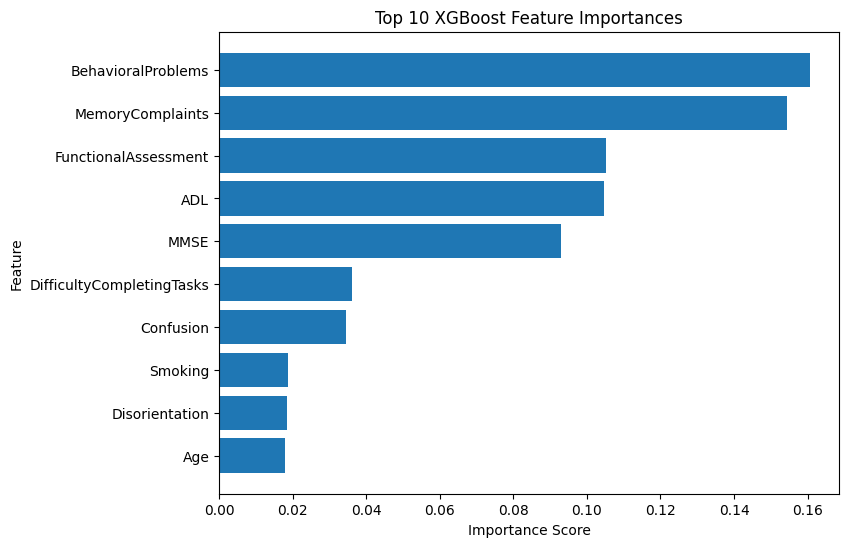

In [17]:
# Select top 10 most important features
top_features = feature_importance.head(10)

# Create horizontal bar plot
plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importances")

# Make most important feature appear at the top
plt.gca().invert_yaxis()

plt.show()

In [18]:
# Features suspected of leaking diagnostic information: these are cognitive/behavioral
# assessments that may be part of how "Diagnosis" was determined in the first place,
# rather than independent risk factors
leakage_suspects = ['MMSE', 'FunctionalAssessment', 'MemoryComplaints',
                     'BehavioralProblems', 'ADL', 'Confusion',
                     'Disorientation', 'DifficultyCompletingTasks', 'Forgetfulness']

# Remove suspects to test whether remaining features have real predictive signal
features_no_leak = [f for f in features if f not in leakage_suspects]

X_nl = data[features_no_leak]
y_nl = data.Diagnosis

X_train_nl, X_valid_nl, y_train_nl, y_valid_nl = train_test_split(
    X_nl, y_nl, train_size=0.8, test_size=0.2, stratify=y_nl, random_state=0
)

# Rebuild a preprocessor for this smaller feature set
numerical_cols_nl = [c for c in X_train_nl.columns if X_train_nl[c].dtype in ['int64', 'float64']]
categorical_cols_nl = [c for c in X_train_nl.columns if X_train_nl[c].dtype == 'object']

preprocessor_nl = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='constant'), numerical_cols_nl),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols_nl)
])

pipeline_nl = Pipeline(steps=[
    ('preprocessor', preprocessor_nl),
    ('model', XGBClassifier(random_state=0, n_estimators=500, learning_rate=0.1))
])

pipeline_nl.fit(X_train_nl, y_train_nl)
preds_nl = pipeline_nl.predict(X_valid_nl)
probs_nl = pipeline_nl.predict_proba(X_valid_nl)[:, 1]

print("Accuracy WITHOUT cognitive/functional features:", accuracy_score(y_valid_nl, preds_nl))
print("ROC-AUC WITHOUT cognitive/functional features:", roc_auc_score(y_valid_nl, probs_nl))
print(classification_report(y_valid_nl, preds_nl))

Accuracy WITHOUT cognitive/functional features: 0.586046511627907
ROC-AUC WITHOUT cognitive/functional features: 0.47531711472926924
              precision    recall  f1-score   support

           0       0.64      0.80      0.71       278
           1       0.35      0.19      0.25       152

    accuracy                           0.59       430
   macro avg       0.49      0.50      0.48       430
weighted avg       0.54      0.59      0.55       430



## SHAP Interpretability

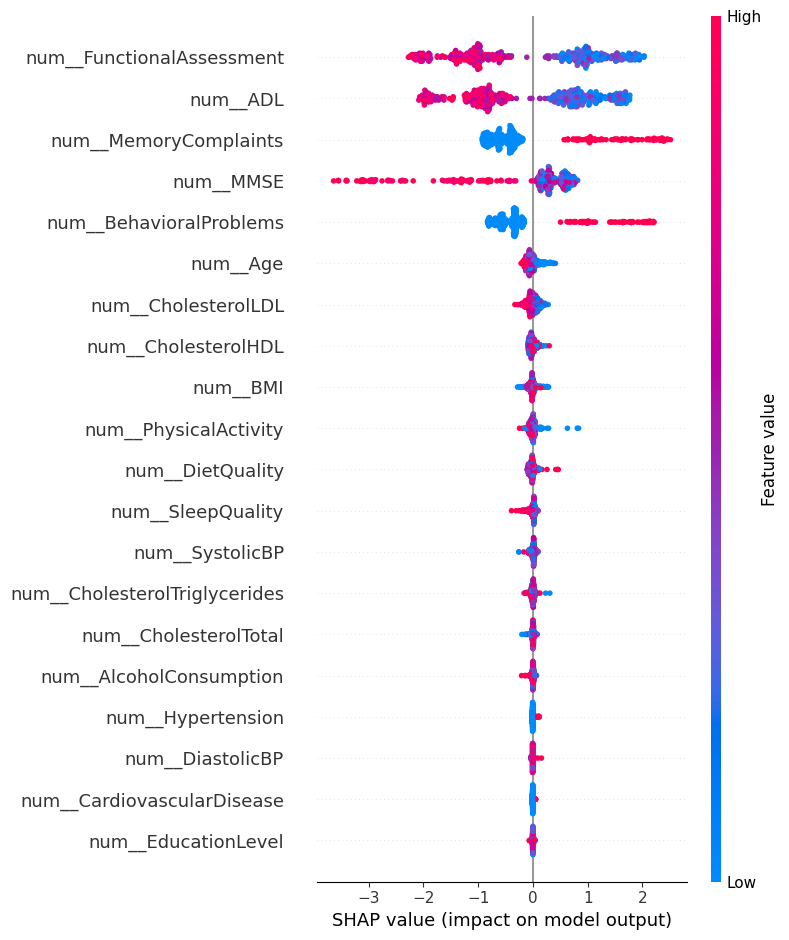

In [19]:
# Transform validation data through the preprocessor to get feature names
X_valid_transformed = best_pipeline.named_steps['preprocessor'].transform(X_valid)
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

explainer = shap.TreeExplainer(best_pipeline.named_steps['model'])
shap_values = explainer.shap_values(X_valid_transformed)

shap.summary_plot(shap_values, X_valid_transformed, feature_names=feature_names)

The SHAP summary plot shows which features had the greatest influence on the model's predictions. Features are ranked from most important at the top to least important at the bottom. The x-axis shows the SHAP value, where positive values push the model toward predicting Alzheimer's and negative values push the model toward predicting No Alzheimer's. The color represents the feature value, with pink indicating higher values and blue indicating lower values.

The most influential features were FunctionalAssessment, ADL, MemoryComplaints, MMSE, and BehavioralProblems. Lower FunctionalAssessment and ADL values tended to push the model toward predicting Alzheimer's, while higher values pushed the model away from Alzheimer's. Higher MemoryComplaints and BehavioralProblems values also pushed the model toward predicting Alzheimer's. Lower MMSE scores increased the model's prediction toward Alzheimer's, which is consistent with MMSE being a cognitive assessment measure.

Overall, the SHAP plot suggests that the model relied mostly on cognitive, functional, and behavioral indicators rather than general health variables such as cholesterol, BMI, blood pressure, smoking, or physical activity. This improves interpretability because the model's strongest predictors are clinically meaningful. However, it also raises a potential concern: features such as MMSE, ADL, FunctionalAssessment, and MemoryComplaints may be highly diagnostic and closely tied to the target label. Therefore, the high model performance should be interpreted carefully and followed by a leakage investigation.

## Limitations

This project is exploratory and should not be interpreted as a clinically validated diagnostic tool. The dataset is public and may not fully represent real-world clinical populations. The model was trained on tabular clinical and lifestyle features rather than MRI, PET, genetic, or biomarker data, so it cannot capture the full biological complexity of Alzheimer’s disease.

A key finding of this project is that model performance depends almost entirely on cognitive and functional assessment (MMSE, FunctionalAssessment, MemoryComplaints, BehavioralProblems, ADL). When these are removed, the model's ROC-AUC drops to ~0.48, indicating that demographic,  lifestyle, and general medical history variables in this dataset carry little to  no independent signal for Alzheimer's diagnosis. This suggests these cognitive features are closely tied to (or possibly derived from) the diagnostic criteria itself, rather than being independent predictors measured prior to diagnosis.  Any claim of a "predictive" model should be understood in that context. This is better described as a model that recovers diagnostic labels from correlated clinical assessments, not one that anticipates Alzheimer's from upstream risk factors.

Furthermore, the initial model showed a training/validation accuracy gap (1.0 vs. ~0.96), suggesting overfitting. Hyperparameter tuning with RandomizedSearchCV (stronger regularization, shallower trees) narrowed this gap (training accuracy dropped to ~0.96) without meaningfully changing validation performance, indicating the original model's validation results were already fairly stable.

Although XGBoost performed well, the results may not generalize to external hospital datasets without further validation. Future work should test the model on independent datasets, include neuroimaging or biomarker variables, and use explainability methods such as SHAP to better understand individual predictions.

## Conclusion 
In this project, I built an XGBoost classification model to predict Alzheimer’s disease diagnosis using clinical, demographic, lifestyle, and cognitive features. I first explored the dataset, visualized important patterns, trained a Random Forest baseline model and an XGBoost model, evaluated performance using multiple metrics, and examined feature importance.

Importantly, further investigation revealed that this performance is driven almost entirely by cognitive and functional assessment features rather than demographic or lifestyle factors, a finding that reframes the project's contribution from "a predictive model" to "a demonstration of how tightly certain features are coupled to the diagnostic label" in this dataset.

The model identified several clinically relevant variables as important predictors, such as cognitive and functional assessment measures. This suggests that machine learning can detect meaningful patterns in structured health data. However, because the dataset is limited and not externally validated, the model should be viewed as an educational and exploratory analysis rather than a diagnostic system.

Overall, this project helped me practice a full biomedical machine learning workflow, including data cleaning, exploratory analysis, model training, evaluation, and interpretation.

## What I Learned
This project taught me that high model performance in clinical ML can be misleading when features overlap with diagnostic criteria. The most important part of the project was not maximizing accuracy, but identifying when the model was learning from features that may not be valid independent predictors.